In [72]:
import numpy as np


In [73]:
data = np.genfromtxt(
    "ipl2025.csv",
    delimiter=",",
    skip_header=1,
    dtype=str,      
    encoding="utf-8"
)

print(data.shape)
print(data[:5])

(74, 34)
[['0' '0' '1' '"March 22' '2025"' '"Eden Gardens' ' Kolkata"' 'KKR' 'RCB'
  'League' 'RCB' 'Bowl' '174.0' '8.0' '177.0' '3.0' 'completed' 'RCB' ''
  '7' '22.0' 'Krunal Pandya' 'Virat Kohli' '59.0' 'Krunal Pandya' '3--29'
  '1' '342.0' '9.0' '5.0' '0.0' '11.0' '0.0' '7.0']
 ['1' '1' '2' '"March 23' '2025"' '"Rajiv Gandhi International Stadium'
  ' Hyderabad"' 'SRH' 'RR' 'League' 'RR' 'Bowl' '286.0' '6.0' '242.0'
  '6.0' 'completed' 'SRH' '44' '' '0.0' 'Ishan Kishan' 'Ishan Kishan'
  '106.0' 'Tushar Deshpande' '3--44' '2' '497.0' '30.0' '16.0' '5.0'
  '12.0' '44.0' '-1.0']
 ['2' '2' '3' '"March 23' '2025"' '"MA Chidambaram Stadium' ' Chennai"'
  'CSK' 'MI' 'League' 'CSK' 'Bowl' '155.0' '9.0' '158.0' '6.0'
  'completed' 'CSK' '' '4' '5.0' 'Noor Ahmad' 'Rachin Ravindra' '65.0'
  'Noor Ahmad' '4--18' '3' '298.0' '15.0' '7.0' '1.0' '15.0' '0.0' '4.0']
 ['3' '3' '4' '"March 24' '2025"' '"ACA-VDCA Cricket Stadium'
  ' Vishakhapatnam"' 'DC' 'LSG' 'League' 'DC' 'Bowl' '209.0' '8.0'
  '2

In [74]:
print(data)

[['0' '0' '1' ... '11.0' '0.0' '7.0']
 ['1' '1' '2' ... '12.0' '44.0' '-1.0']
 ['2' '2' '3' ... '15.0' '0.0' '4.0']
 ...
 ['71' '71' '72' ... '11.0' '20.0' '-1.0']
 ['72' '72' '73' ... '11.0' '0.0' '5.0']
 ['73' '73' '74' ... '16.0' '6.0' '-1.0']]


In [75]:
win_by_runs = data[:,32]
print(win_by_runs)

['0.0' '44.0' '0.0' '0.0' '11.0' '0.0' '0.0' '50.0' '36.0' '0.0' '6.0'
 '0.0' '0.0' '0.0' '80.0' '12.0' '25.0' '50.0' '0.0' '12.0' '4.0' '18.0'
 '58.0' '0.0' '0.0' '0.0' '0.0' '0.0' '12.0' '0.0' '16.0' '0.0' '0.0'
 '0.0' '0.0' '2.0' '0.0' '0.0' '39.0' '0.0' '0.0' '11.0' '0.0' '' '54.0'
 '0.0' '0.0' '14.0' '0.0' '100.0' '38.0' '2.0' '1.0' '37.0' '' '8.0' '0.0'
 '' '10.0' '0.0' '0.0' '0.0' '59.0' '33.0' '42.0' '0.0' '83.0' '110.0'
 '0.0' '0.0' '0.0' '20.0' '0.0' '6.0']


In [76]:
win_by_runs = np.array([int(float(x)) if x != '' else 0 for x in data[:, 32]])
win_by_wickets = np.array([int(float(x)) if x != '' else 0 for x in data[:, 33]])
total_extras = np.array([int(float(x))if x !=''else 0 for x in data[:, 28]])
total_run_off_bat = np.array([int(float(x))if x != ''else 0 for x in data[:,27]])

print(win_by_runs[:5])
print(win_by_wickets[:5])
print(total_extras[:5])
print(total_run_off_bat[:5])


[ 0 44  0  0 11]
[ 7 -1  4  1 -1]
[ 9 30 15 15 24]
[342 497 298 405 449]


In [77]:
print("Max runs:", win_by_runs.max())
print("Min runs:", win_by_runs.min())


print("Mean wickets:", win_by_wickets.mean())
print("Median wickets:", np.median(win_by_wickets))
print("Std wickets:", win_by_wickets.std())

Max runs: 110
Min runs: 0
Mean wickets: 2.7027027027027026
Median wickets: 0.0
Std wickets: 3.9309229015029366


In [78]:
# Winning team scored more than 50 runs
runs_gt_50 = data[win_by_runs > 50]

# Matches decided by wickets (win_by_runs = 0)
wickets_win = data[win_by_runs == 0]


In [79]:
print(runs_gt_50[:,14])

['120.0' '159.0' '161.0' '117.0' '121.0' '147.0' '168.0']


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns


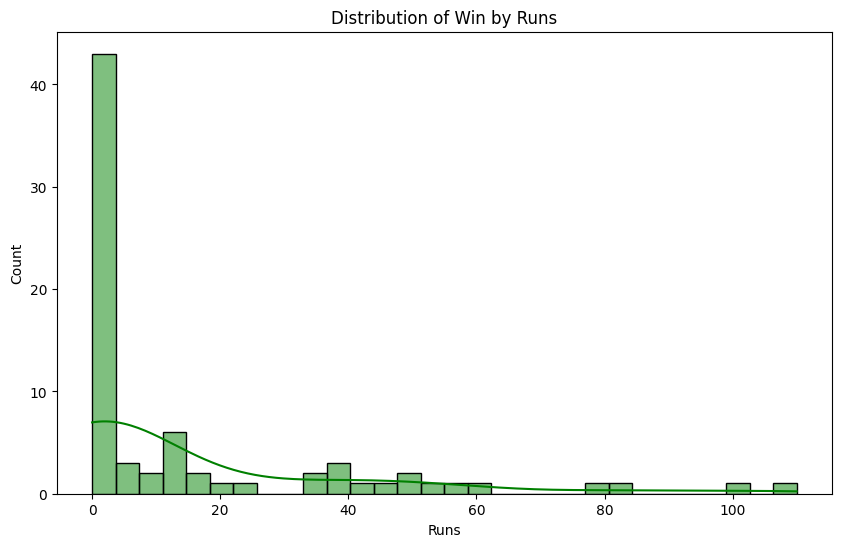

In [81]:

plt.figure(figsize=(10,6))
sns.histplot(win_by_runs, bins=30, kde=True, color='green')
plt.title('Distribution of Win by Runs')
plt.xlabel('Runs')
plt.ylabel('Count')
plt.show()


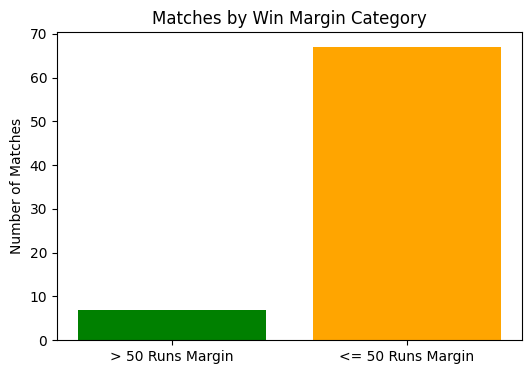

In [82]:
large_margin = np.sum(win_by_runs > 50)
small_margin = np.sum(win_by_runs <= 50)

plt.figure(figsize=(6,4))
plt.bar(['> 50 Runs Margin', '<= 50 Runs Margin'], [large_margin, small_margin], color=['green', 'orange'])
plt.title('Matches by Win Margin Category')
plt.ylabel('Number of Matches')
plt.show()


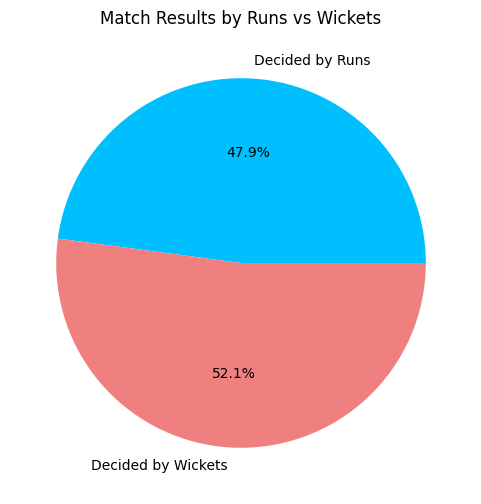

In [83]:
matches_by_runs = np.sum(win_by_runs > 0)
matches_by_wickets = np.sum(win_by_wickets > 0)

plt.figure(figsize=(6,6))
plt.pie([matches_by_runs, matches_by_wickets], labels=['Decided by Runs', 'Decided by Wickets'], autopct='%1.1f%%', colors=['deepskyblue', 'lightcoral'])
plt.title('Match Results by Runs vs Wickets')
plt.show()


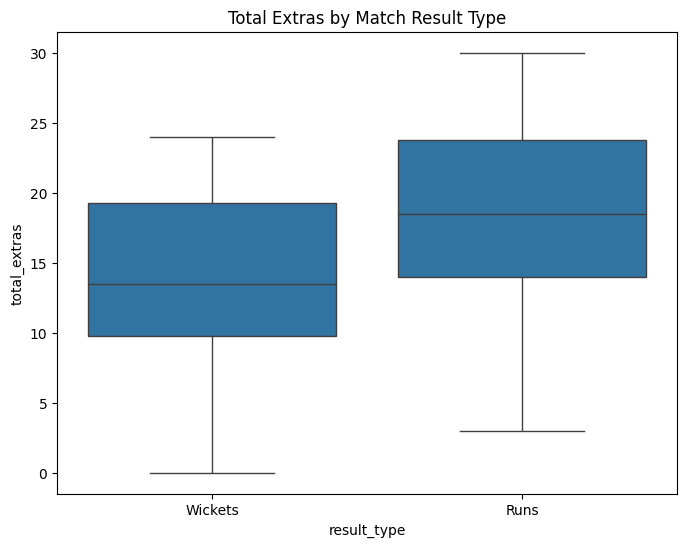

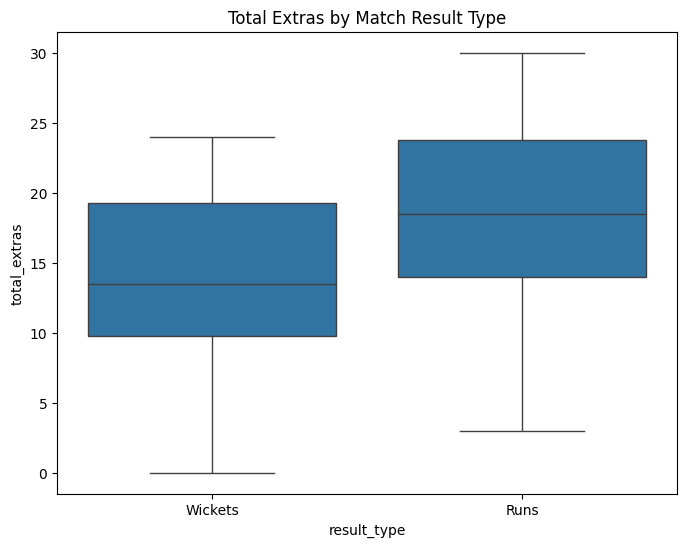

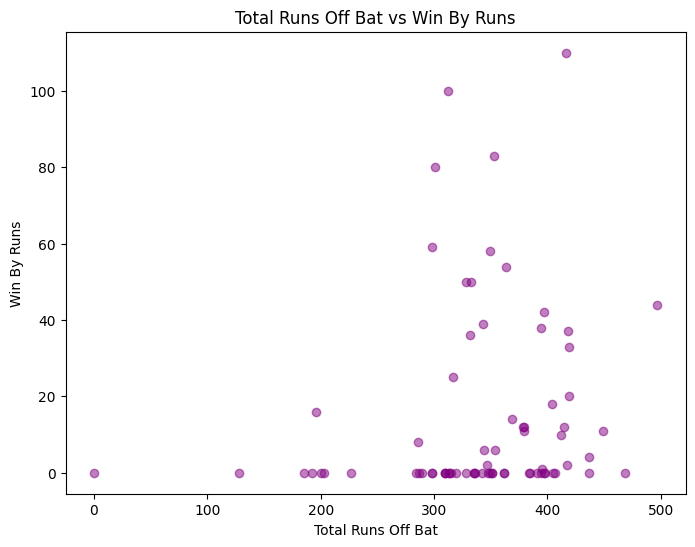

In [84]:
import pandas as pd
df = pd.DataFrame({
    'win_by_runs': win_by_runs,
    'win_by_wickets': win_by_wickets,
    'total_extras': total_extras
})

df['result_type'] = np.where(df['win_by_runs'] > 0, 'Runs', 'Wickets')

plt.figure(figsize=(8,6))
sns.boxplot(x='result_type', y='total_extras', data=df)
plt.title('Total Extras by Match Result Type')
plt.show()

df['result_type'] = np.where(df['win_by_runs'] > 0, 'Runs', 'Wickets')

plt.figure(figsize=(8,6))
sns.boxplot(x='result_type', y='total_extras', data=df)
plt.title('Total Extras by Match Result Type')
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(total_run_off_bat, win_by_runs, alpha=0.5, c='purple')
plt.title('Total Runs Off Bat vs Win By Runs')
plt.xlabel('Total Runs Off Bat')
plt.ylabel('Win By Runs')
plt.show()

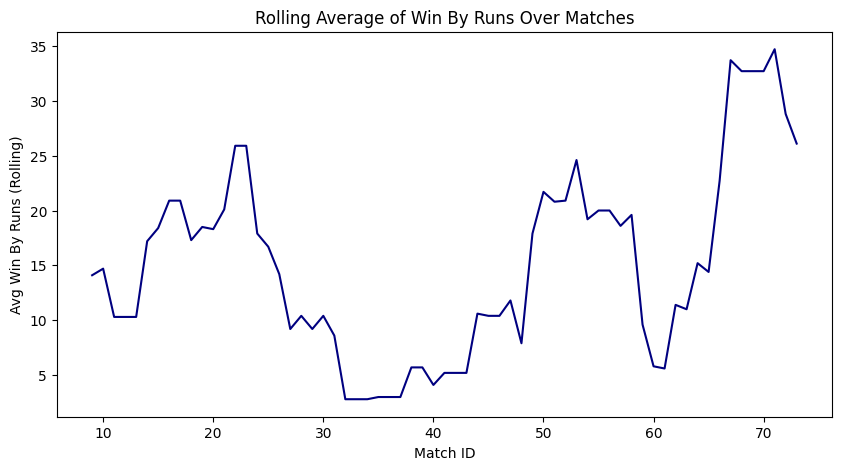

In [85]:

match_ids = data[:,1].astype(int)
df= pd.DataFrame({'match_id': match_ids, 'win_by_runs': win_by_runs})
avg_win_runs = df.groupby('match_id')['win_by_runs'].mean().rolling(window=10).mean()

plt.figure(figsize=(10,5))
plt.plot(avg_win_runs, color='navy')
plt.title('Rolling Average of Win By Runs Over Matches')
plt.xlabel('Match ID')
plt.ylabel('Avg Win By Runs (Rolling)')
plt.show()


In [86]:
df = pd.DataFrame({
    'match_ids': match_ids,
    'win_by_runs': win_by_runs,
    'win_by_wickets': win_by_wickets,
    'total_extras': total_extras
})

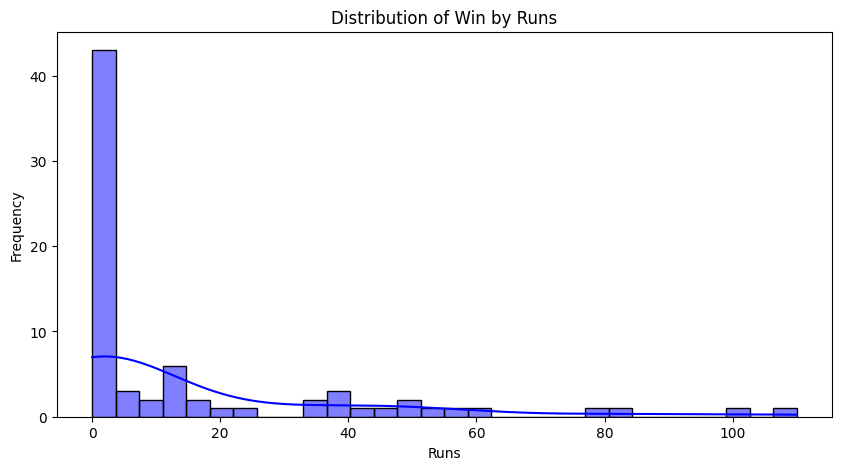

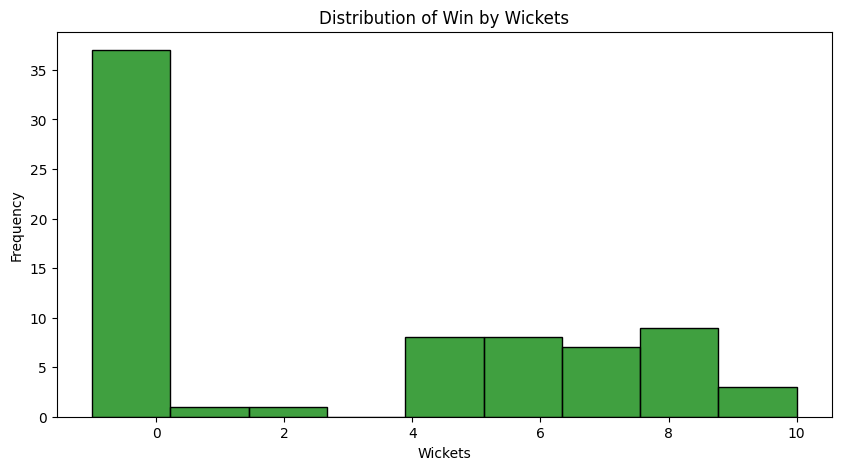

In [87]:
plt.figure(figsize=(10,5))
sns.histplot(df['win_by_runs'], bins=30, kde=True, color='blue')
plt.title("Distribution of Win by Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['win_by_wickets'], bins=9, kde=False, color='green')
plt.title("Distribution of Win by Wickets")
plt.xlabel("Wickets")
plt.ylabel("Frequency")
plt.show()


In [88]:
print(df.columns.tolist())


['match_ids', 'win_by_runs', 'win_by_wickets', 'total_extras']


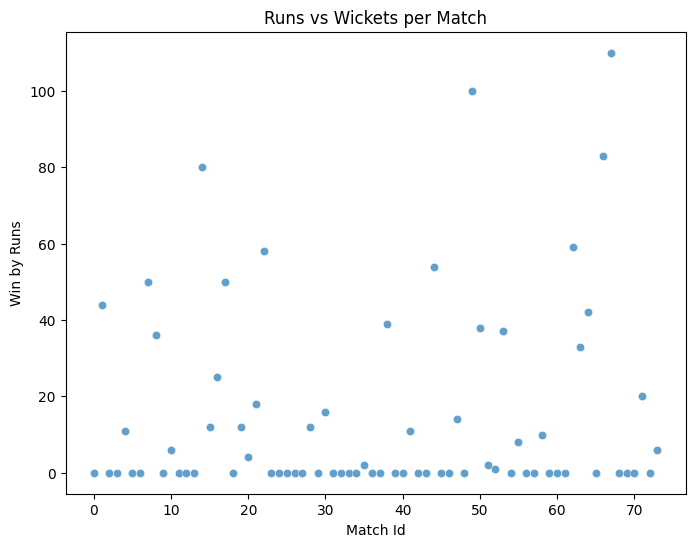

In [90]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='match_ids', y='win_by_runs', data=df, alpha=0.7)
plt.title("Runs vs Wickets per Match")
plt.xlabel("Match Id")
plt.ylabel("Win by Runs")
plt.show()
